In [1]:
%matplotlib widget
from typing import Optional, Iterable
import xarray as xr
import numpy  as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib as mpl
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import warnings
from metpy.calc import smooth_n_point
from IPython.display import display
from ipywidgets import HBox, Image
from minisom import MiniSom

In [38]:
def get_num_pcs(vrnce: xr.DataArray, tol: float) -> int:
    cumvrnce = vrnce.cumsum()
    if (cumvrnce > tol).any():
        return (cumvrnce - tol).where(cumvrnce > tol).argmin().values.tolist() + 1
    else:
        warnings.warn(
            "the cumulative variance does not reach the specified tolerance",
            RuntimeWarning,
            2,
        )
        return vrnce.pcrank.size + 1


def return_dataspace(X: xr.DataArray, EOFs: xr.DataArray) -> xr.DataArray:
    return xr.apply_ufunc(
        lambda A, B: (A @ B.T).squeeze(),
        X,
        EOFs.sel(pcrank=X.pcrank).stack(grid=["lat", "lon"]),
        input_core_dims=[["pcrank"], ["pcrank"]],
    ).unstack()


def wrapped_kmeans(
    pcds: xr.Dataset,
    var_thresh: Optional[float] = 0.95,
    output_dataspace: bool = True,
    **kmeans_kwargs,
) -> tuple[xr.DataArray, np.array]:
    kmeans_kwargs.setdefault("n_clusters", 4)
    kmeans_kwargs.setdefault("tol", 1e-6)
    kmeans_kwargs.setdefault("max_iter", 300)
    if var_thresh is not None:
        n_features = get_num_pcs(pcds["vrnce"], var_thresh)
    else:
        n_features = pcds["pcrank"].size
    kmm = KMeans(**kmeans_kwargs)
    kmm.fit(pcds["PC"].isel(pcrank=slice(n_features)))
    if kmm.n_iter_ >= kmeans_kwargs["max_iter"]:
        warnings.warn(f"did not converge to specified tol in {kmm.n_iter_} iterations")
    else:
        print(f"converged in {kmm.n_iter_} iterations")
    centers = xr.DataArray(
        kmm.cluster_centers_,
        dims=["n_clusters", "pcrank"],
        coords={
            "n_clusters": np.arange(1, kmeans_kwargs["n_clusters"] + 1),
            "pcrank": np.arange(n_features),
        },
    )
    if output_dataspace:
        centers = return_dataspace(centers, pcds["EOF"])
    return centers, (kmm.labels_ + 1)

def multivar_kmeans(
    pcdsets: Iterable[xr.Dataset], var_thresh: float = 0.95, **kmeans_kwargs
):
    pcs: list[xr.DataArray] = []
    eofs: list[xr.DataArray] = []
    npcs = [get_num_pcs(ds["vrnce"], var_thresh) for ds in pcdsets]
    for npc, ds in zip(npcs, pcdsets):
        pc = ds["PC"].isel(pcrank=slice(npc))
        eof = ds["EOF"].isel(pcrank=slice(npc))
        pcstart = pcs[-1]["pcrank"][-1].values + 1 if pcs else 0
        pcs.append(pc.assign_coords(pcrank=np.arange(pcstart, pcstart + npc)))
        eofs.append(eof.assign_coords(pcrank=np.arange(pcstart, pcstart + npc)))
    pcds = xr.concat(pcs, "pcrank").to_dataset()
    centers, labels = wrapped_kmeans(
        pcds, var_thresh=None, output_dataspace=False, **kmeans_kwargs
    )
    all_centers = []
    for i in range(len(pcdsets)):
        start = np.cumsum(npcs)[i - 1] if i > 0 else 0
        stop = np.cumsum(npcs)[i]
        all_centers.append(
            return_dataspace(
                centers.isel(pcrank=slice(start, stop)),
                eofs[i],
            )
        )
    return all_centers, labels

def cluster_plot(
    centers: xr.DataArray,
    figname: Optional[str] = None,
    labels: Optional[np.ndarray] = None,
    clim: Optional[xr.DataArray] = None,
):
    if figname is not None:
        mpl.rcParams.update({"figure.dpi": 300})
    if labels is not None:
        unique_labels, counts = np.unique(labels, return_counts=True)
        sorted_counts = counts[np.argsort(unique_labels)]

    lonmin, lonmax = centers["lon"][[0, -1]].values
    latmin, latmax = centers["lat"][[0, -1]].values
    proj = ccrs.LambertConformal(
        central_latitude=(latmin + latmax * 3) / 4,
        central_longitude=(lonmin + lonmax) / 2,
    )
    proj._threshold /= 100
    transproj = ccrs.PlateCarree()
    corners = [(n, m) for n in [lonmin, lonmax] for m in [latmin, latmax]]
    corners[2], corners[3] = corners[3], corners[2]
    bord_poly = mpath.Path(corners)
    grid = centers.plot(
        col="n_clusters",
        # vmin=-15,
        center=0,
        col_wrap=2,
        robust=True,
        transform=transproj,
        subplot_kws={"projection": proj},
        cbar_kwargs={"location": "bottom", "label": "1/s", "aspect": 30},
    )
    for i, ax in enumerate(grid.axs.flatten()):
        ax: GeoAxes
        if i < centers.n_clusters.size:
            ax.coastlines(color="gray")
            if labels is not None:
                ax.set_title(
                    f"cluster {i+1}, {sorted_counts[i]} days ({sorted_counts[i]/labels.size*100:.0f}%)"
                )
            ax.set_extent([lonmin, lonmax, latmin, latmax], crs=transproj)
            ax.set_boundary(bord_poly, transform=transproj)
            if clim is not None:
                smooth_n_point(clim, n=9).metpy.dequantify().plot.contour(
                    ax=ax,
                    transform=transproj,
                    colors="k",
                    levels=10,
                    linewidths=1.25,
                    add_labels=False,
                )
    plt.subplots_adjust(hspace=0.1, bottom=0.2)
    if figname is not None:
        plt.savefig("figs/" + figname)
        mpl.rcParams.update({"figure.dpi": 100})
    else:
        plt.show()
    plt.close(1)

In [3]:
root = Path("MERRA2/stats")
pv_pcs = xr.open_dataset(root / "MERRA2.qgpv_vint_EOFs_all_days.1980_2023.nc")
lwa_pcs = xr.open_dataset(root / "MERRA2.LWA_vint_EOFs_all_days.1980_2023.nc")
u_pcs = xr.open_dataset(root / "MERRA2.UG_vint_EOFs_all_days.1980_2023.nc")
alwa_pcs = xr.open_dataset(root / "MERRA2.AeLm_vint_EOFs_all_days.1980_2023.nc")
alwa_pcs["EOF"] *= -1
clwa_pcs = xr.open_dataset(root / "MERRA2.AeLp_vint_EOFs_all_days.1980_2023.nc")
# pv_clim = (
#     xr.open_dataset(root / "MERRA2.qgpv_vint_mean_all_days.1980_2023.nc")["qgpv_vint"]
#     .sel(month=0)
#     .squeeze()
# )
# lwa_clim = (
#     xr.open_dataset(root / "MERRA2.LWA_vint_mean_all_days.1980_2023.nc")["AeL_vint"]
#     .sel(month=0)
#     .squeeze()
# )

In [29]:
print(get_num_pcs(pv_pcs.vrnce, 0.99))
print(pv_pcs.EOF.sel(pcrank=0).size)
pv_pcs.EOF.sizes

127
23040


Frozen({'pcrank': 507, 'lat': 120, 'lon': 192})

In [ ]:
# pv_centers, pv_labels = wrapped_kmeans(pv_pcs, var_thresh=0.95, n_clusters=5, tol=1e-10)
# lwa_centers, lwa_labels = wrapped_kmeans(lwa_pcs, var_thresh=0.9, n_clusters=5, tol=1e-8)
# alwa_centers, alwa_labels = wrapped_kmeans(alwa_pcs, var_thresh=0.9, n_clusters=5, tol=1e-8)
# calwa_centers, calwa_labels = multivar_kmeans(
#     [alwa_pcs, clwa_pcs], 0.9, n_clusters=5, tol=1e-10
# )
# ulwa_centers, ulwa_labels = multivar_kmeans(
#     [u_pcs, lwa_pcs], 0.9, n_clusters=5, tol=1e-10
# )
ualwa_centers, ualwa_labels = multivar_kmeans(
    [u_pcs, alwa_pcs], 0.9, n_clusters=5, tol=1e-10
)

converged in 205 iterations
converged in 55 iterations


In [67]:
neurons = int(5*np.sqrt(pv_pcs.time.size))
nx = int(np.sqrt(neurons)) + 1
num_pcs = get_num_pcs(pv_pcs.vrnce, 0.99)
som = MiniSom(1, 5, num_pcs, learning_rate=0.2, sigma=0.4, activation_distance='cosine')
data = pv_pcs.PC.isel(pcrank=slice(num_pcs)).transpose('time','pcrank').values
som.random_weights_init(data)
som.train_batch(data,20000)
winners = som.win_map(data, return_indices=True)

In [68]:
print(som.quantization_error(data))
print(som.topographic_error(data))

0.0045301340065242515
0.491942007342418


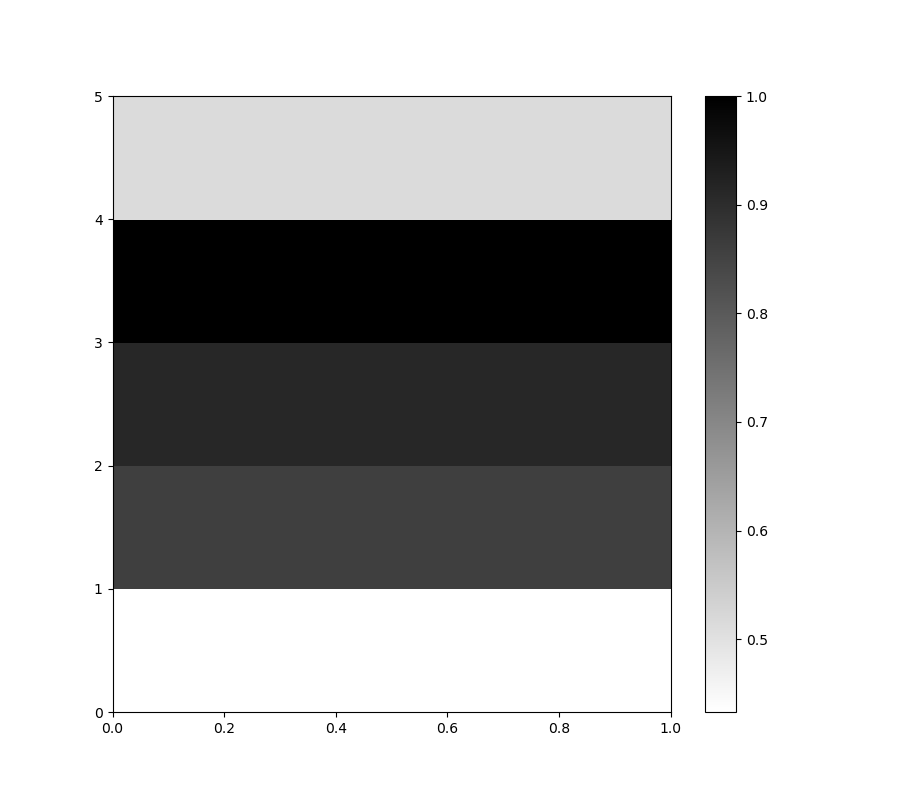

In [69]:
plt.close('all')
plt.figure(figsize=(9, 8))
plt.pcolor(som.distance_map().T, cmap='gist_yarg') 
plt.colorbar()

In [70]:
labels = {pv_pcs.time[i].values:key[1] for key, inds in winners.items() for i in inds}
labels = [labels[lab] for lab in sorted(labels)]

In [72]:
pvPC = pv_pcs["PC"]
pvPC["pv_labels"] = ("time", labels)
cluster_centers = return_dataspace(pvPC.groupby("pv_labels").mean(), pv_pcs.EOF).rename(pv_labels="n_clusters")

In [140]:
lwaPC = lwa_pcs["PC"]
lwaPC["pv_labels"] = ("time", pv_labels)
lwa_comp_with_pv = return_dataspace(
    lwaPC.groupby("pv_labels").mean(), lwa_pcs.EOF
).rename(pv_labels="n_clusters")

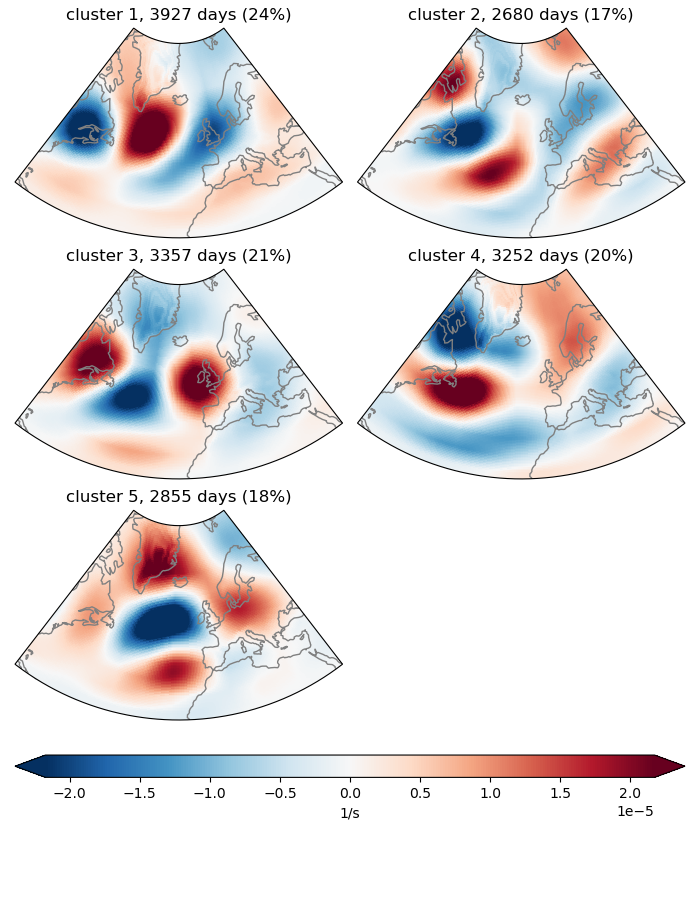

In [73]:
# plt.close("all")
cluster_plot(cluster_centers, labels=np.array(labels))
# cluster_plot(pv_centers, "MERRA2.pv_clusters_5.1980_2023.png", pv_labels, clim=pv_clim)
# cluster_plot(lwa_centers, "MERRA2.lwa_clusters_5.1980_2023.png", lwa_labels)
# cluster_plot(alwa_centers, "MERRA2.alwa_clusters_5.1980_2023.png", alwa_labels)
# cluster_plot(ualwa_centers[1], "MERRA2.alwa_ubiclusters_5.1980_2023.png", ualwa_labels)
# cluster_plot(calwa_centers[0], "MERRA2.alwa_biclusters_5.1980_2023.png", calwa_labels)
# cluster_plot(calwa_centers[1], "MERRA2.clwa_biclusters_5.1980_2023.png", calwa_labels)
# cluster_plot(ulwa_centers[0], "MERRA2.u_biclusters_5.1980_2023.png", ulwa_labels)
# cluster_plot(ulwa_centers[1], "MERRA2.lwa_biclusters_5.1980_2023.png", ulwa_labels)
# cluster_plot(lwa_comp_with_pv, "MERRA2.lwa_comp_with_pv.1980_2023.png", pv_labels)


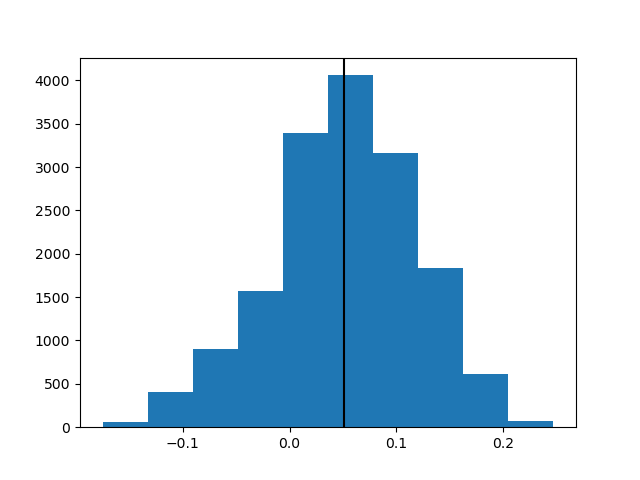

In [17]:
plt.close("all")
# pv_silhouettes = silhouette_samples(
#     pv_pcs.PC.isel(pcrank=slice(get_num_pcs(pv_pcs.vrnce, 0.95))).values, pv_labels
# )
pv_silhouettes = silhouette_samples(
    alwa_pcs.PC.isel(pcrank=slice(get_num_pcs(lwa_pcs.vrnce, 0.9))).values, alwa_labels
)
xr.DataArray(pv_silhouettes, dims=["time"], coords={"time": pv_pcs.time}).plot.hist()
plt.axvline(pv_silhouettes.mean(), c="k")

In [18]:
scale = "45%"
figs = []
for f in [
    # "MERRA2.lwa_biclusters_5.1980_2023.png",
    # "MERRA2.lwa_clusters_5.1980_2023.png",
    # "MERRA2.u_biclusters_5.1980_2023.png",
    "MERRA2.alwa_clusters_5.1980_2023.png",
    "MERRA2.alwa_ubiclusters_5.1980_2023.png",
    # "MERRA2.clwa_biclusters_5.1980_2023.png",
]:
    with open("figs/" + f, "rb") as im:
        figs.append(Image(value=im.read(), height=scale, width=scale))
display(HBox(figs))

<img src="figs/MERRA2.lwa_clusters_5.1980_2023.png" height="60%" width="60%">
<!-- <img src="figs/MERRA2.pv_clusters_5.1980_2023.png" height="60%" width="60%"> -->
<img src="figs/Cassou2008_Fig1_wide.png" height="60%" width="60%">